<img src="recursos/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Trabajo Práctico de Laboratorio 1

Docentes: *LLAMEDO SORIA, Mariano* y *MOHAROS, David*

Integrantes: *MARCHESI, Matías Sebastián*, *PARISEK, Alan Nicolas* y *RODRIGUEZ SILVOSA, Martín*

Grupo 4

Autor: *MARCHESI, Matías Sebastián*

## Introducción

El filtro que realizaremos para esta práctica de laboratorio es un **Notch**, las especificaciones son las siguientes:

<div style="text-align: center;">
  <img src="recursos/notch_specs.png" width="500">
</div>

Primero se realizará un análisis numérico haciendo los cálculos de los componentes, luego se simulará el circuito en LTSpice y por último fabricaremos la placa diseñándola en KiCad y utilizando el sistema CNC con una fresadora que cale el cobre.

## Análisis

Para el análisis numérico seguiremos la plantilla pedida:
$$\alpha_{max} = 3dB$$
$$BW = 10Hz$$
$$f_0 = 50Hz$$

Al tratarse de un filtro notch de segundo orden, su función transferencia normalizada se escribe como:

$$\large T(s) = \frac{s^2 + \omega_0^2}{s^2 + \frac{\omega_0}{Q} + \omega_0^2}$$

$$\omega_0 = 2\pi f_0 = 314.159 rad/s$$

Con estos datos puedo calcular el factor de calidad (Q), siendo que:

$$BW = \frac{f_0}{Q} \Rightarrow Q = 5$$


Sabiendo que el ancho de banda (BW) es $10Hz$ sé que:
$$f_1 \approx 45Hz$$
$$f_2 \approx 55Hz$$

Son valores aproximados ya que por definición:
$$f_0^2 = f_1 \cdot f_2$$
Por lo que no es exactamente igual.


Para este laboratorio implementaremos una topología KHN. Esto porque nos es conveniente el poder ajustar tanto la $\omega_0$ y el $Q$ de manera independiente, facilitando más la obtención de los parámetros buscados cuando lo probemos. Además, esta topología permite implementar en simultáneo una respuesta LP, BP y HP, y luego a partir de alguna salida de esas podremos implementar el Notch con más facilidad.

Para la obtención del circuito nos basamos en el libro de **"Design of analog filters" pág 380**

<div style="text-align: center;">
  <img src="recursos/khn_libro.png" width="500">
</div>

De allí solamente utilizamos el circuito hasta la sección eliminabanda. O sea, el primer bloque.

Llevandolo a circuito en LTSpice obtenemos:

<div style="text-align: center;">
  <img src="recursos/khn_spice.png" width="600">
</div>

Para obtener la transferencia utilizaremos un script de python que nos calcule directamente la transferencia planteando las ecuaciones de nodos usando admitancias. Además se hará el planteo de kirchoff en cada nodo para obtener las expresiones de corriente en cada lugar. Por último se obtendrán todos los desarrollos y se expresarán como una transferencia más sencilla de leer.

In [66]:
import sympy as sp
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
import math

# Parámetros:
Y1, Y2, Y3, Y4, Y5, Y6, Y7, Y8, Y9, Y10, Y11 = sp.symbols("Y1, Y2, Y3, Y4, Y5, Y6, Y7, Y8, Y9, Y10, Y11")
Vi, Vo, Va, Vb, Vc, Vd, Ve, Vf, Vg = sp.symbols("Vi, Vo, Va, Vb, Vc, Vd, Ve, Vf, Vg")
G1, G2, G3, G4, G5, G6, G7, G8, G9, C1, C2, wt, w0 = sp.symbols("G1, G2, G3, G4, G5, G6, G7, G8, G9, C1, C2, wt, w0", real=True, positive=True) 
s = sp.symbols('s')

# Ecuaciones de nodos
eq1 = Va*(Y3+Y10+Y1+Y2) - Vi*Y3 - Vb*Y10 - Vb*Y1 - Vf*Y2
eq2 = Va*1
eq3 = Vc*(Y4+Y11) - Vb*Y4 - Vd*Y11
eq4 = Vc*1
eq5 = Ve*(Y5+Y6) - Vd*Y5 - Vf*Y6
eq6 = Ve*1
eq7 = Vg*(Y8+Y7+Y9) - Vb*Y8 - Vi*Y7 - Vo*Y9
eq8 = Vg*1

solucion = sp.solve([eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8], [Vo, Va, Vb, Vc, Vd, Ve, Vf, Vg], dict=True)


# Calculamos la transferencia T = Vo / Vi
Vo_resuelto = solucion[0][Vo]
T = sp.simplify(Vo_resuelto / Vi)

T_s = T.subs({
    Y1: G1,
    Y2: G2,
    Y3: G3,
    Y4: G4,
    Y5: G5,
    Y6: G6,
    Y7: G7,
    Y8: G8,
    Y9: G9,
    Y10: s*C1,
    Y11: s*C2
})

# Simplificación
T_s = sp.together(T_s)
T_s = sp.factor(T_s)
T_s = sp.simplify(T_s)

### Impresión llevando a un formato más cómodo la transferencia

# print_latex(a_equal_b_latex_s('T(s)', T_s))

divisor = C1*C2*G6*G9

num, den = sp.fraction(T_s)

num_dividido = sp.collect(sp.expand(num / divisor), s, evaluate=sp.simplify)
den_dividido = sp.collect(sp.expand(den / divisor), s, evaluate=sp.simplify)

T_s = num_dividido / den_dividido

# Impresión del resultado final con componentes
print_latex(a_equal_b_latex_s('T(s)', T_s))

<IPython.core.display.Math object>

Con la transferencia obtenida ahora la voy a simplificar para mayor facilidad en la lectura. Para eso tomaré ciertos valores de componentes como iguales.

$$GA = G1 = G3$$
$$GB = G5 = G6 = G7 = G8 = G9$$
$$GC = G2 = G4 = G5$$
$$C = C1 = C2$$

Así queda la transferencia:

$$\large T(s) = -\frac{s^2 +s(\frac{GA \cdot GB}{C^2} - \frac{GA \cdot GB}{C^2}) + \frac{GC^2 \cdot GB^2}{C^2 \cdot GB^2}}{s^2 + s\frac{GA}{C} + \frac{GC^2 \cdot GB}{C^2 \cdot GB}}$$

Cancelando:

$$\large T(s) = -\frac{s^2 +\cancel{s(\frac{GA \cdot GB}{C^2} - \frac{GA \cdot GB}{C^2})} + \frac{GC^2 \cdot \cancel{GB^2}}{C^2 \cdot \cancel{GB^2}}}{s^2 + s\frac{GA}{C} + \frac{GC^2 \cdot \cancel{GB}}{C^2 \cdot \cancel{GB}}}$$

Finalmente:

$$\large T(s) = -\frac{s^2 + \frac{GC^2}{C^2}}{s^2 + s\frac{GA}{C} + \frac{GC^2}{C^2}}$$

Comparando con la transferencia genérica:
$$\large T(s) = \frac{s^2 + \omega_0^2}{s^2 + s\frac{\omega_0}{Q} + \omega_0^2}$$

* $\large \omega_0^2 = 98696.044 = \frac{GC^2}{C^2}$
* $\large \frac{\omega_0}{Q} = 62.832 = \frac{GA}{C}$

Asumo todos los capacitores $C = 100\eta F$.

Con eso despejo los valores de $GA$ y $GC$.

$$GC = 31.4159 \micro S mS \Rightarrow RC = 31830.988 \Omega$$

$$RC = R2 = R4 = 32\ K\Omega$$

$$GA = 6.2832 \micro S  \Rightarrow RA = 159154.571 \Omega$$

$$RA = R1 = R3 = 159.15 K\Omega \approx 160K\Omega$$

Falta obtener $GB$, por eso asumo que:
$$RB = R5 = R6 = R7 = R8 = R9 = 10K\Omega$$

Finalmente los valores de los componentes son:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$
\begin{array}{c|c}
\text{Componente} & \text{Valor} \\ \hline
C_1 & 100\,\mathrm{nF} \\
C_2 & 100\,\mathrm{nF} \\
R_1 & 160\,\mathrm{K}\Omega \\
R_2 & 32\,\mathrm{K}\Omega \\
R_3 & 160\,\mathrm{K}\Omega \\
R_4 & 32\,\mathrm{K}\Omega \\
R_5 & 10\,\mathrm{K}\Omega \\
R_6 & 10\,\mathrm{K}\Omega \\
R_7 & 10\,\mathrm{K}\Omega \\
R_8 & 10\,\mathrm{K}\Omega \\
R_9 & 10\,\mathrm{K}\Omega
\end{array}
$$
    </div>
</div>






## Simulaciones

### Python

Primero procedo a simular con un script de python la transferencia y fase, el retardo de grupo y los polos y ceros. Además se adjunta una verificación de cumplimiento de los parámetros de la plantilla:

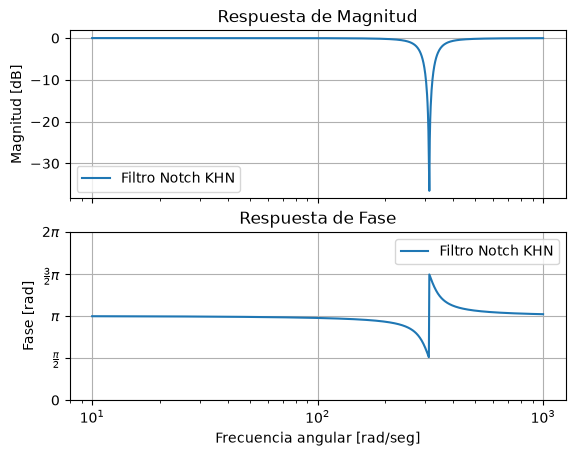

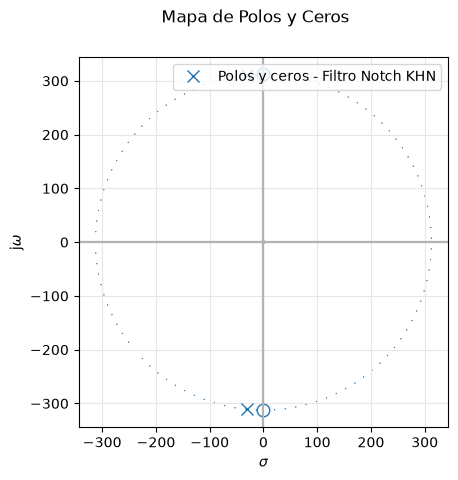

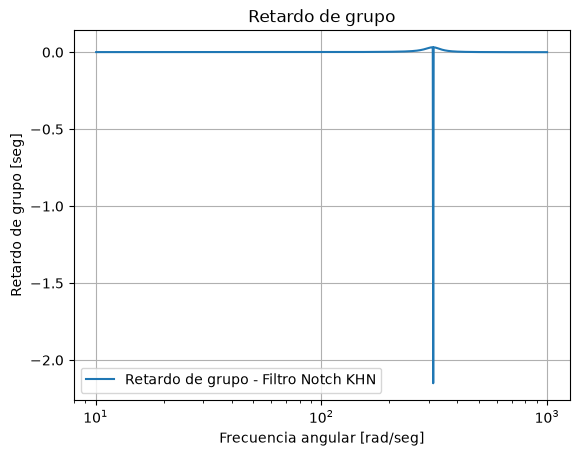

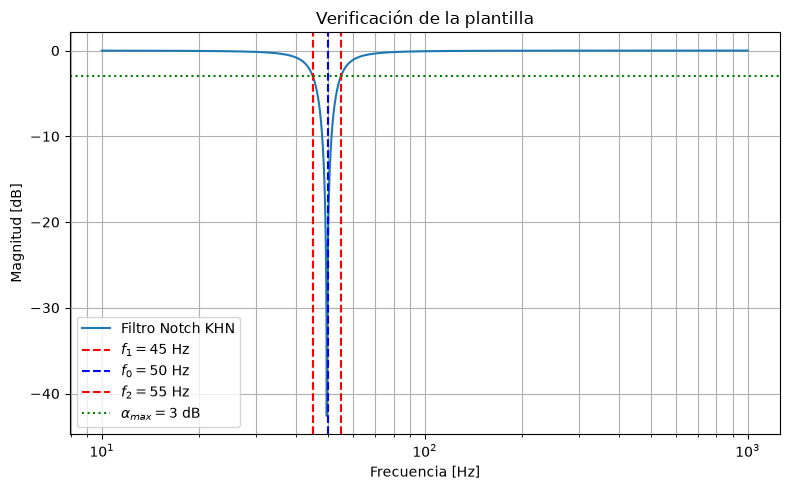

In [67]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

from pytc2.general import s, symbfunc2tf
from pytc2.sistemas_lineales import pzmap, GroupDelay

GC = 1/32e3
GA = 1/160e3

C1 = C2 = 100e-9

T = -(
    s**2 + (GC**2)/(C1*C2)
) / (
    s**2 + s*GA/C1 + (GC**2)/(C1*C2)
)

T = sp.factor(T)

T_tf = symbfunc2tf(T)


f = np.logspace(1, 3, 2000)
w = 2*np.pi*f

T_func = sp.lambdify(s, T, 'numpy')

H = T_func(1j*w)

magnitud = 20*np.log10(np.abs(H))
fase = np.unwrap(np.angle(H))

bodePlot(
    T_tf,
    fig_id=1,
    filter_description='Filtro Notch KHN'
)

plt.show()

pzmap(
    T_tf,
    fig_id=2,
    filter_description='Polos y ceros - Filtro Notch KHN'
)

plt.show()

GroupDelay(
    T_tf,
    fig_id=3,
    filter_description='Retardo de grupo - Filtro Notch KHN'
)

plt.show()

# VERIFICACIÓN DE LA PLANTILLA

f1 = 45
f0 = 50
f2 = 55
alpha_max = 3

H_verificacion = T_func(
    1j * 2*np.pi*np.array([f1, f0, f2])
)

magnitud_verificacion = 20*np.log10(
    np.abs(H_verificacion)
)


fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(
    f,
    magnitud,
    label='Filtro Notch KHN'
)

# Frecuencias de la plantilla
ax.axvline(
    f1,
    color='red',
    linestyle='--',
    label='$f_1 = 45$ Hz'
)

ax.axvline(
    f0,
    color='blue',
    linestyle='--',
    label='$f_0 = 50$ Hz'
)

ax.axvline(
    f2,
    color='red',
    linestyle='--',
    label='$f_2 = 55$ Hz'
)

# Atenuación máxima
ax.axhline(
    -alpha_max,
    color='green',
    linestyle=':',
    label='$\\alpha_{max} = 3$ dB'
)

ax.set_title('Verificación de la plantilla')
ax.set_xlabel('Frecuencia [Hz]')
ax.set_ylabel('Magnitud [dB]')

ax.grid(True, which='both')
ax.legend()

plt.tight_layout()
plt.show()

En la verificación aparece levemente desplazada la línea de $f_0$, esto es por la normalización de los componentes, ya que habíamos obtenido valores de $RA = 159.15K\Omega$ y $RC = 31.8K\Omega$ por lo que tiene sentido que se desplace un poco.

### LTSpice

Se adjunta a su vez la simulación obtenida en LTSPice.

Se presenta el circuito con sus valores:
<div style="text-align: center;">
  <img src="recursos/khn_spice_convalores.png" width="600">
</div>

Se simula la respuesta en frecuencia con la directiva `.ac dec 10000 1 1K` y colocando un generador como entrada de $V_i$ y se obtiene:

#### Módulo

<div style="text-align: center;">
  <img src="recursos/khn_spice_modulo.png" width="550">
</div>

#### Fase

<div style="text-align: center;">
  <img src="recursos/khn_spice_fase.png" width="550">
</div>

#### Retardo de grupo
<div style="text-align: center;">
  <img src="recursos/khn_spice_retardo.png" width="550">
</div>

Nótese que tanto la fase como el retardo de grupo presentan una discontinuidad en los 50Hz. Esto es por el cero del filtro. Idealmente se deberían ver valores muy altos de retardo de grupo cuando se aproxime a ese cero de transmisión.

Se podría mejorar la simulación si se incrementara el número de puntos, pero igualmente seguiría habiendo una discontinuidad.

## Diseño y fabricación de la placa

Una vez finalizado el análisis y la simulación del filtro, se realizó el diseño de la placa de circuito impreso utilizando KiCad. A partir del esquemático utilizado durante el diseño, se realizó la asignación de footprints, el diseño del PCB y el ruteo de las pistas.

La placa fue fabricada mediante una máquina CNC utilizando una fresadora. Posteriormente se realizó el montaje de los componentes y la conexión de los terminales correspondientes a la alimentación, entrada y salida del circuito.

El diseño final de la placa se incluye como parte de la entrega.

### Modificaciones para el ajuste en laboratorio

Para facilitar el ajuste experimental de los parámetros del filtro, se incorporaron
potenciómetros en serie con algunas de las resistencias externas al circuito integrado.
Estas resistencias intervienen en la determinación de $\omega_0$, $Q$ y de los pesos
utilizados en el sumador.

Se buscó disponer de un rango de ajuste del orden del $\pm20\%$ respecto de los valores
nominales obtenidos durante el diseño. Para una resistencia nominal $R_N$, se consideró:

$$
R_{\min}=R_N(1-0.20)
$$

$$
R_{\max}=R_N(1+0.20)
$$

A partir de estos valores se seleccionaron resistencias fijas y potenciómetros con
valores comerciales, procurando que el valor nominal quedara dentro del rango de
ajuste.

Para $R_1$ y $R_3$, cuyo valor nominal es $160\,k\Omega$, el rango teórico para una
variación del $\pm20\%$ es:

$$
128\,k\Omega \leq R \leq 192\,k\Omega
$$

Se implementaron mediante una resistencia fija de $130\,k\Omega$ y un potenciómetro
de $50\,k\Omega$, obteniendo un rango práctico de:

$$
130\,k\Omega \leq R_1,R_3 \leq 180\,k\Omega
$$

Por otro lado, para $R_4$ y $R_7$, cuyo valor nominal es $32\,k\Omega$, el rango
teórico es:

$$
25.6\,k\Omega \leq R \leq 38.4\,k\Omega
$$

Se utilizaron resistencias fijas de $30\,k\Omega$ y potenciómetros de $10\,k\Omega$,
obteniendo:

$$
30\,k\Omega \leq R_4,R_7 \leq 40\,k\Omega
$$

Se deja expresado con una tabla:

$$
\begin{array}{c|c|c}
\text{Componente} & \text{Implementación} & \text{Rango} \\ \hline
R_1 & 130\,\mathrm{K}\Omega + RV_2(50\,K\Omega) & 130\ a\ 180\,K\Omega \\
R_3 & 130\,\mathrm{K}\Omega + RV_1(50\,K\Omega) & 130\ a\ 180\,K\Omega \\
R_4 & 30\,\mathrm{K}\Omega + RV_4(10\,K\Omega) & 30\ a\ 40\,K\Omega \\
R_7 & 30\,\mathrm{K}\Omega + RV_3(10\,K\Omega) & 30\ a\ 40\,K\Omega
\end{array}
$$

### Diseño de la placa

Una vez definidos los valores de los componentes y las modificaciones necesarias para
permitir el ajuste experimental, se realizó el diseño de la placa de circuito impreso
utilizando KiCad.

A partir del esquemático del circuito se realizó la distribución de los componentes y
el ruteo de las pistas, teniendo en cuenta la ubicación de los conectores de entrada,
salida y alimentación, así como la accesibilidad de los potenciómetros para facilitar
su ajuste durante las mediciones.

<div style="text-align: center;">
  <img src="recursos/khn_esquematico.png" width="700">
</div>

A su vez, se colocaron capacitores de $100\eta F$ a las entradas de $VCC$ y $VEE$ para filtrar cualquier ruido que pueda ingresar por la fuente. También se pusieron testpoints en varios puntos de la placa.

Eso luego se volcó en un PCB de cobre, haciéndolo solo en una capa.

<div style="text-align: center;">
  <img src="recursos/khn_ruteo.png" width="600">
</div>

### Fabricación y montaje de la placa

La placa fue fabricada mediante una máquina CNC utilizando una fresadora. Una vez finalizado el fresado,
se realizó el montaje y soldadura de los componentes.

Los potenciómetros fueron ubicados de manera que resultaran accesibles durante la
etapa de caracterización experimental, permitiendo modificar los parámetros del filtro
sin necesidad de reemplazar componentes.

## Laboratorio

Se realizará un script de Python que vuelque en una tabla los valores obtenidos y graficará como quedó la respuesta en frecuencia del filtro.

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datos medidos

datos = {
    'Frecuencia [Hz]': [20, 40, 57.5, 59.7, 61.9, 64.1, 66.3, 68.5,
                        69.6, 70.7, 72.9, 75.1, 77.3, 79.5, 80.8, 100, 150],

    'Vout [V]': [10, 9.1, 7.1, 6, 5.32, 4.51, 3.64, 5.95,
                 2.83, 3.07, 4, 5.5, 6.48, 7.2, 7.1, 9.27, 9.27],

    'Desfasaje [ms]': [25.2, 13.6, 10, 9.7, 9.3, 8.9, 8.2, 7.3,
                       6.7, 7.5, 7.7, 7.8, 7.6, 7.4, 7.2, 5.5, 3.48]
}

df = pd.DataFrame(datos)

# Mostrar tabla
df

,Frecuencia [Hz],Vout [V],Desfasaje [ms]
0,20.0,10.00,25.20
1,40.0,9.10,13.60
2,57.5,7.10,10.00
3,59.7,6.00,9.70
4,61.9,5.32,9.30
5,64.1,4.51,8.90
6,66.3,3.64,8.20
7,68.5,5.95,7.30
8,69.6,2.83,6.70
9,70.7,3.07,7.50


In [69]:

# Cálculo de ganancia y fase

Vin = 10       # Vpp
f = df['Frecuencia [Hz]']

# Ganancia lineal
df['|H|'] = df['Vout [V]'] / Vin

# Ganancia en dB
df['|H| [dB]'] = 20 * np.log10(df['|H|'])

# Fase a partir del desfasaje temporal
df['Fase [°]'] = -360 * f * df['Desfasaje [ms]'] * 1e-3

df

,Frecuencia [Hz],Vout [V],Desfasaje [ms],|H|,|H| [dB],Fase [°]
0,20.0,10.00,25.20,1.000,0.000000,-181.4400
1,40.0,9.10,13.60,0.910,-0.819172,-195.8400
2,57.5,7.10,10.00,0.710,-2.974833,-207.0000
3,59.7,6.00,9.70,0.600,-4.436975,-208.4724
4,61.9,5.32,9.30,0.532,-5.481767,-207.2412
5,64.1,4.51,8.90,0.451,-6.916469,-205.3764
6,66.3,3.64,8.20,0.364,-8.777972,-195.7176
7,68.5,5.95,7.30,0.595,-4.509661,-180.0180
8,69.6,2.83,6.70,0.283,-10.964271,-167.8752
9,70.7,3.07,7.50,0.307,-10.257232,-190.8900


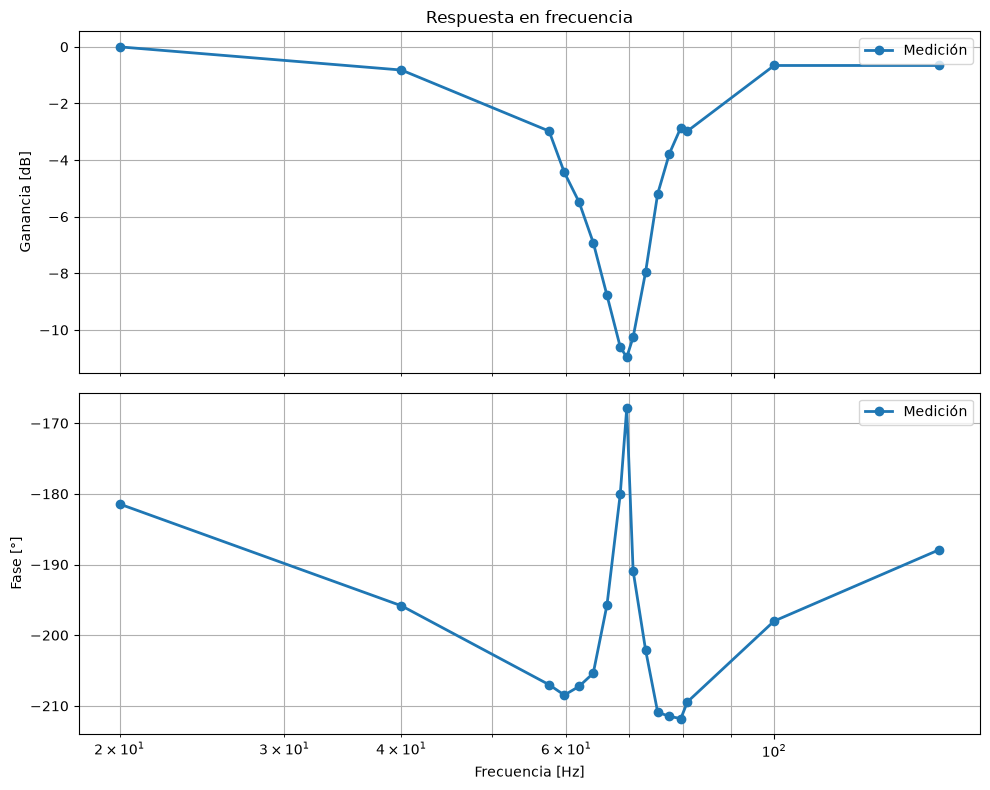

In [70]:
import numpy as np
import matplotlib.pyplot as plt


# Datos medidos

frecuencia = np.array([
    20.0, 40.0, 57.5, 59.7, 61.9, 64.1, 66.3, 68.5,
    69.6, 70.7, 72.9, 75.1, 77.3, 79.5, 80.8, 100.0, 150.0
])

ganancia = np.array([
    10.0, 9.1, 7.1, 6.0, 5.32, 4.51, 3.64, 2.95,
    2.83, 3.07, 4.0, 5.5, 6.48, 7.2, 7.1, 9.27, 9.27
])

fase_ms = np.array([
    25.2, 13.6, 10.0, 9.7, 9.3, 8.9, 8.2, 7.3,
    6.7, 7.5, 7.7, 7.8, 7.6, 7.4, 7.2, 5.5, 3.48
])


Vin = 10.0  # Vpp

ganancia_lineal = ganancia / Vin
ganancia_dB = 20 * np.log10(ganancia_lineal)

# Fase a partir del desfasaje temporal
fase_grados = -fase_ms * frecuencia * 0.36


fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


# Módulo
ax[0].semilogx(
    frecuencia,
    ganancia_dB,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Medición'
)

ax[0].set_title('Respuesta en frecuencia')
ax[0].set_ylabel('Ganancia [dB]')
ax[0].grid(True, which='both')
ax[0].legend()


# Fase
ax[1].semilogx(
    frecuencia,
    fase_grados,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Medición'
)

ax[1].set_xlabel('Frecuencia [Hz]')
ax[1].set_ylabel('Fase [°]')
ax[1].grid(True, which='both')
ax[1].legend()


plt.tight_layout()
plt.show()

Luego medimos la placa con el analizador de espectros y obtuvimos otros valores. Por eso genero otro script que haga el gráfico partiendo de ese barrido en frecuencia.

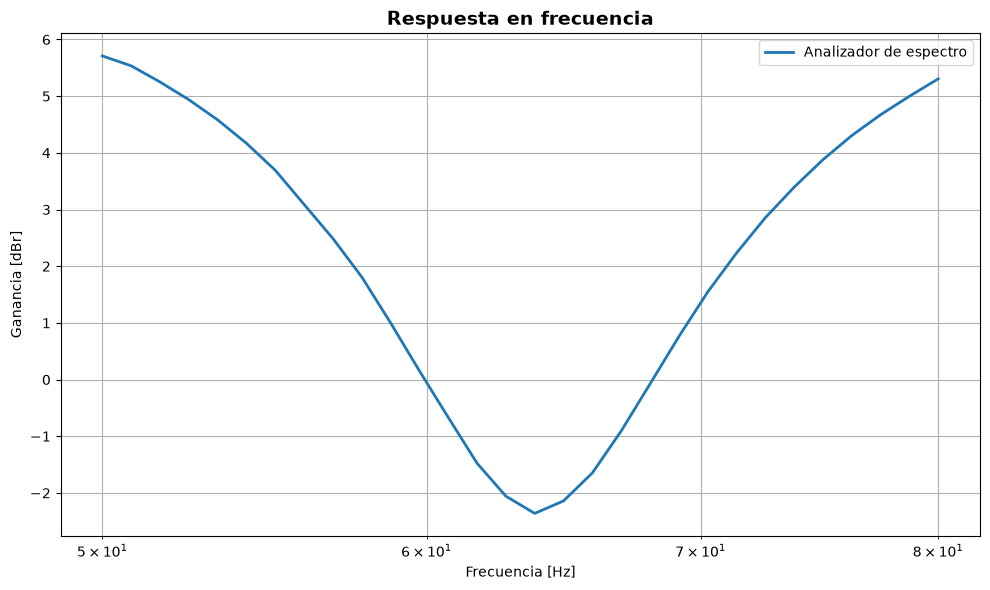

In [71]:
import pandas as pd
import matplotlib.pyplot as plt


# Lectura del barrido del analizador de espectro

archivo = "recursos/barrido.csv"

with open(archivo, "r", encoding="utf-8") as f:
    lineas = f.readlines()

inicio = next(
    i for i, linea in enumerate(lineas)
    if "Vac vs Frequency" in linea
)

datos = pd.read_csv(
    archivo,
    skiprows=inicio + 1
)

# Gráfico

frecuencia = datos["X (Hz)"]
ganancia_dB = datos["Ch-2 (dBr)"]

plt.figure(figsize=(10, 6))

plt.semilogx(
    frecuencia,
    ganancia_dB,
    linewidth=2,
    label="Analizador de espectro"
)

plt.title(
    "Respuesta en frecuencia",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ganancia [dBr]")

plt.grid(True, which="both")
plt.legend()

plt.tight_layout()
plt.show()

Por último se agrega un script que junte ambos gráficos y haga partir a ambos de $0dB$ para poder compararlos.

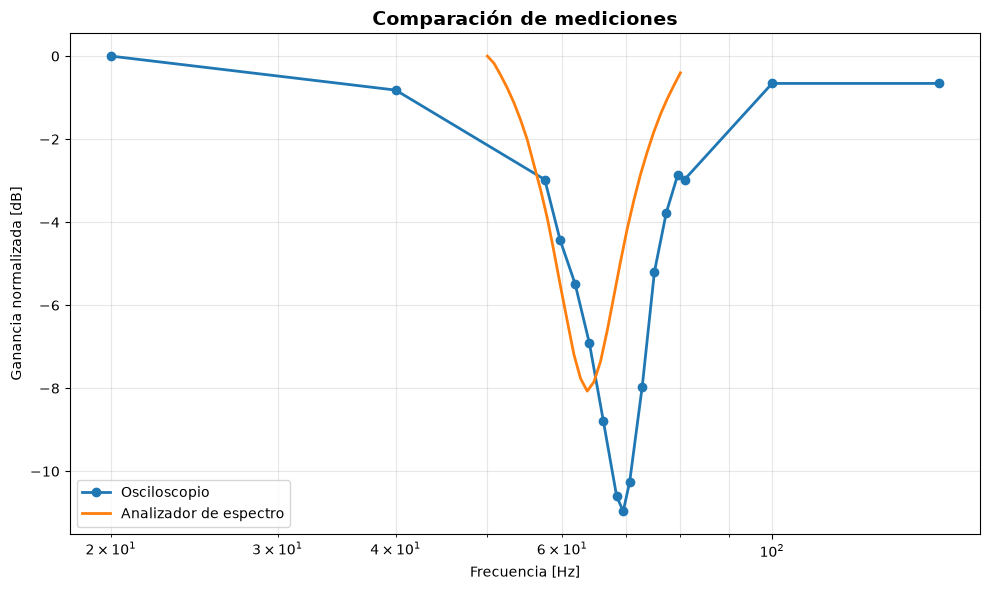

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Osciloscopio

frecuencia_osc = np.array([
    20.0, 40.0, 57.5, 59.7, 61.9, 64.1, 66.3, 68.5,
    69.6, 70.7, 72.9, 75.1, 77.3, 79.5, 80.8, 100.0, 150.0
])

ganancia_osc = np.array([
    10.0, 9.1, 7.1, 6.0, 5.32, 4.51, 3.64, 2.95,
    2.83, 3.07, 4.0, 5.5, 6.48, 7.2, 7.1, 9.27, 9.27
])

Vin = 10.0  # Vpp

# Ganancia en dB
ganancia_osc_dB = 20 * np.log10(ganancia_osc / Vin)


# Analizador de espectro

path = "recursos/barrido.csv"

with open(path, "r") as f:
    lineas = f.readlines()

inicio = next(
    i for i, linea in enumerate(lineas)
    if "Vac vs Frequency" in linea
)

datos = pd.read_csv(
    path,
    skiprows=inicio + 1
)

frecuencia_analizador = datos["X (Hz)"].to_numpy()
ganancia_analizador_dB = datos["Ch-2 (dBr)"].to_numpy()


# Llevar ambas curvas a 0 dB en su máximo
ganancia_osc_norm = ganancia_osc_dB - np.max(ganancia_osc_dB)
ganancia_analizador_norm = (
    ganancia_analizador_dB - np.max(ganancia_analizador_dB)
)


# Comparación

plt.figure(figsize=(10, 6))

plt.semilogx(
    frecuencia_osc,
    ganancia_osc_norm,
    marker='o',
    linewidth=2,
    label='Osciloscopio'
)

plt.semilogx(
    frecuencia_analizador,
    ganancia_analizador_norm,
    linewidth=2,
    label='Analizador de espectro'
)

plt.title(
    'Comparación de mediciones',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Ganancia normalizada [dB]')

plt.grid(True, which='both', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Conclusiones

En base a todos los gráficos expuestos en las previas secciones queda demostrado que nuestro filtro Notch varió en su comportamiento en laboratorio respecto de lo que habíamos calculado teóricamente.

### Diferencias entre Osciloscopio y Analizador de espectro

Antes de analizar las diferencias entre lo teórico y lo realizado en la práctica, se puede observar que entre lo medido con el analizador de espectro y el osciloscopio se obtienen variaciones.

El punto más bajo medido con el osciloscopio ronda los $-11dB$, mientras que en el analizador de espectro ronda los $-8dB$. Además, se observa un desplazamiento en la frecuencia correspondiente al mínimo de la respuesta. En el osciloscopio, este se encuentra aproximadamente en $69,6Hz$, mientras que en el analizador de espectro se encuentra alrededor de los $64Hz$.

Estas diferencias pueden estar relacionadas con las condiciones en las que se realizaron ambas mediciones. En particular, las conexiones realizadas mediante cables BNC-cocodrilo pueden haber introducido ruido y elementos parásitos en el circuito. También existe una posible incertidumbre asociada al instrumental utilizado y a la medición manual del desfasaje mediante el osciloscopio.

A pesar de estas diferencias, ambos métodos permiten observar el mismo comportamiento general del filtro: una atenuación alrededor de la frecuencia de rechazo seguida de una recuperación de la señal al alejarse de dicha frecuencia. Por lo tanto, se puede considerar que ambas mediciones permiten verificar experimentalmente el comportamiento de tipo Notch del circuito.


### Diferencias entre el comportamiento teórico y el experimental

En el diseño teórico se estableció una frecuencia de rechazo de aproximadamente $50\,\mathrm{Hz}$. Sin embargo, durante las mediciones realizadas sobre la placa se observó que la frecuencia correspondiente al mínimo de la respuesta se encontraba alrededor de los $63\,\mathrm{Hz}$.

Este desplazamiento puede atribuirse principalmente al ajuste de los potenciómetros utilizados en el circuito, los cuales no quedaron calibrados exactamente en el valor necesario para obtener la frecuencia de diseño. Esto modifica los valores efectivos de los parámetros del filtro y, por lo tanto, su frecuencia de rechazo.

Además, las tolerancias propias de los componentes, junto con los elementos parásitos introducidos por el montaje y las conexiones utilizadas durante la medición, pueden contribuir a las diferencias observadas respecto del comportamiento teórico.

Por lo tanto, si bien el circuito implementado no alcanzó exactamente las especificaciones planteadas inicialmente, se pudo verificar experimentalmente el comportamiento característico de un filtro Notch. La respuesta, si bien atenuando menos de lo esperado, termina eliminando un rango de frecuencias cercanos al $BW = 10Hz$. 

En resumen, la experiencia nos demostró que hay diferencias entre lo calculado teóricamente y lo realizado en la práctica. Se ve más la importancia del correcto ajuste de los componentes y tomar los mayores recaudos posibles al momento de la medición. A su vez, con mejores componentes que tengan menores tolerancias se podría haber aproximado más aún y ser más fidedigno con lo calculado.